# Statistics for Decision Making on real estate prices in Australia data

###### By Pramod Godse

##### Importing Necessary Libraries

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind
from scipy.stats import binom  # Apply Binomial Distribution
import statsmodels.api as sm   # ANOVA
from statsmodels.formula.api import ols  # ANOVA

##### Loading dataset

In [52]:
df = pd.read_csv('property.csv')
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


##### dataset structure understanding 

In [53]:
# Basic information about dataset
print("Dataset Info:")
print(df.info())
print("\n" + "="*80)
print("\nDataset Statistics:")
print(df.describe())
print("\n" + "="*80)
print("\nColumn Names and Types:")
print(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float

##### Missing Value Analysis

Missing Values in Dataset:
                    Column  Missing_Count  Percentage
BuildingArea  BuildingArea           6450       47.50
YearBuilt        YearBuilt           5375       39.58
CouncilArea    CouncilArea           1369       10.08
Car                    Car             62        0.46


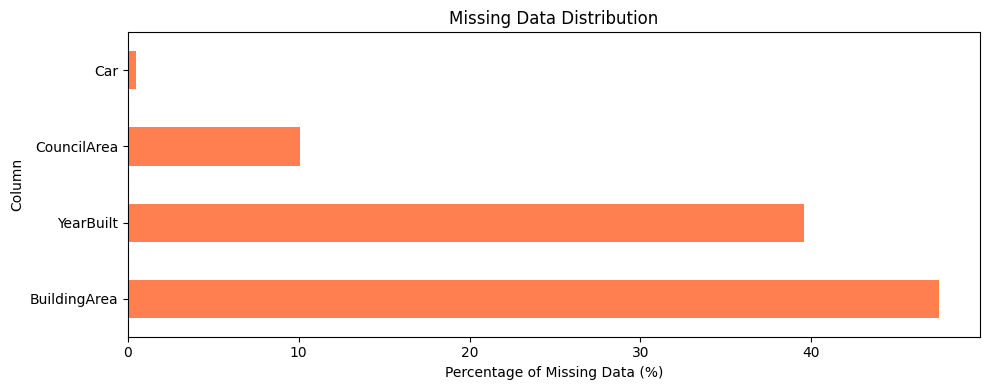

In [54]:
# Identify missing values
print("Missing Values in Dataset:")
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data)

# Visualize missing data
plt.figure(figsize=(10, 4))
missing_data.set_index('Column')['Percentage'].plot(kind='barh', color='coral')
plt.xlabel('Percentage of Missing Data (%)')
plt.title('Missing Data Distribution')
plt.tight_layout()
plt.show()

In [55]:
# Create a working copy of the dataframe
df_cleaned = df.copy()

print("MISSING DATA HANDLING STRATEGIES:")
print("="*80)

# Fill with Median grouped by property type or suburb 'BuildingArea'
print("\n1. BuildingArea (47% Missing)")
print("\n This is too large for mean/median imputation, because it will heavily distort the dataset")
print("\n Strategy is to use Median grouped by property type or suburb")
print(f"   Before: {df_cleaned['BuildingArea'].isnull().sum()} rows")
df_cleaned['BuildingArea'] = df_cleaned['BuildingArea'].fillna(df_cleaned.groupby(['Type','Suburb'])['BuildingArea'].transform('median'))
print(f"   Missing in BuildingArea after fill: {df_cleaned['BuildingArea'].isnull().sum()}")

# Fill with Median year of suburb 'YearBuilt'
print("\n2. YearBuilt (39% Missing)")
print("\n YearBuilt has large missing proportion, so mean/median can still bias")
print("\n Strategy is to use Median year of suburb")
print(f"   Before: {df_cleaned['YearBuilt'].isnull().sum()} rows")
df_cleaned['YearBuilt'] = df_cleaned['YearBuilt'].fillna(df_cleaned.groupby('Suburb')['YearBuilt'].transform('median'))
print(f"   Missing in YearBuilt after fill: {df_cleaned['YearBuilt'].isnull().sum()}")

# Fill with MODE (for categorical 'CouncilArea' column)
print("\n3. CouncilArea (10% Missing)")
print("\n This is categorical")
print("\n Strategy is to use Mode to fill the values")
print(f"   Before: {df_cleaned['CouncilArea'].isnull().sum()} rows")
df_cleaned['CouncilArea'] = df_cleaned['CouncilArea'].fillna(df_cleaned['CouncilArea'].mode()[0])
print(f"   Missing in CouncilArea after fill: {df_cleaned['CouncilArea'].isnull().sum()}")

# Fill with Median 'Car'
print("\n4. Car (0.4% Missing)")
print("\n Very small missing percentage")
print("\n Strategy is to use Median")
print(f"   Before: {df_cleaned['Car'].isnull().sum()} rows")
df_cleaned['Car'] = df_cleaned['Car'].fillna(df_cleaned['Car'].median())
print(f"   Missing in YearBuilt after fill: {df_cleaned['Car'].isnull().sum()}")

print("\n" + "="*80)
print(f"\nFinal Missing Values: {df_cleaned.isnull().sum().sum()}")

MISSING DATA HANDLING STRATEGIES:

1. BuildingArea (47% Missing)

 This is too large for mean/median imputation, because it will heavily distort the dataset

 Strategy is to use Median grouped by property type or suburb
   Before: 6450 rows
   Missing in BuildingArea after fill: 97

2. YearBuilt (39% Missing)

 YearBuilt has large missing proportion, so mean/median can still bias

 Strategy is to use Median year of suburb
   Before: 5375 rows
   Missing in YearBuilt after fill: 18

3. CouncilArea (10% Missing)

 This is categorical

 Strategy is to use Mode to fill the values
   Before: 1369 rows
   Missing in CouncilArea after fill: 0

4. Car (0.4% Missing)

 Very small missing percentage

 Strategy is to use Median
   Before: 62 rows
   Missing in YearBuilt after fill: 0


Final Missing Values: 115


In [56]:
print("FURTHER HADNLING MISSING DATA:")
print("="*80)

# Fallback for remaining missing 'BuildingArea'
print(f"   Before: {df_cleaned['BuildingArea'].isnull().sum()} rows")
df_cleaned['BuildingArea'] = df_cleaned['BuildingArea'].fillna(df_cleaned['BuildingArea'].median())
print(f"   Missing in BuildingArea after fill: {df_cleaned['BuildingArea'].isnull().sum()}")

# Fallback for remaining missing 'YearBuilt'
print(f"   Before: {df_cleaned['YearBuilt'].isnull().sum()} rows")
df_cleaned['YearBuilt'] = df_cleaned['YearBuilt'].fillna(df_cleaned['YearBuilt'].median())
print(f"   Missing in BuildingArea after fill: {df_cleaned['BuildingArea'].isnull().sum()}")

print("\n" + "="*80)
print(f"\nFinal Missing Values: {df_cleaned.isnull().sum().sum()}")

FURTHER HADNLING MISSING DATA:
   Before: 97 rows
   Missing in BuildingArea after fill: 0
   Before: 18 rows
   Missing in BuildingArea after fill: 0


Final Missing Values: 0


##### Descriptive Statistics

In [57]:
df_cleaned.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.611856,558.416127,143.409708,1964.271870,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.960793,3990.669241,393.325228,31.664405,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,97.500000,1950.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,127.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,168.500000,1980.625000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


##### Outlier Detection

In [25]:
df_cleaned.select_dtypes(include=['int64','float64']).columns

Index(['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude',
       'Propertycount'],
      dtype='object')

##### Variables like Suburb, Type, Regionname are categorical → no outlier detection needed.

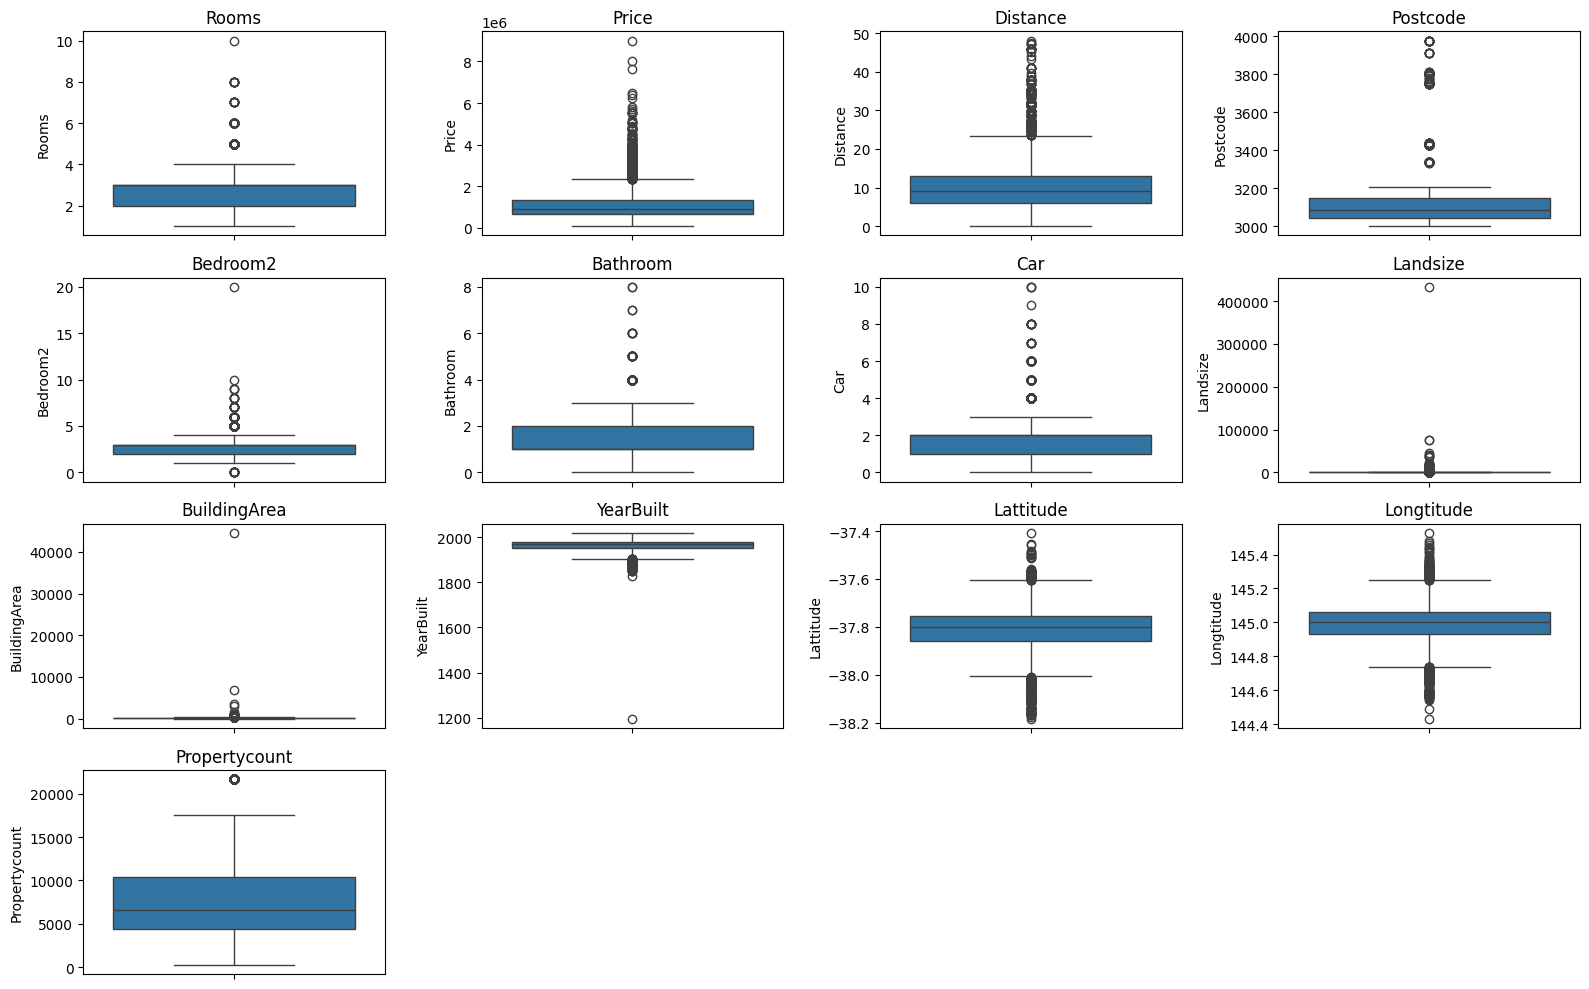

In [33]:
#Boxplot
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(16,10))

for i, col in enumerate(num_cols,1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_cleaned[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [36]:
# IQR Calculation
for col in num_cols:
    
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_cleaned[(df_cleaned[col] < lower) | (df_cleaned[col] > upper)]
    
    print(f"{col} : {len(outliers)} outliers")

Rooms : 682 outliers
Price : 612 outliers
Distance : 411 outliers
Postcode : 208 outliers
Bedroom2 : 655 outliers
Bathroom : 143 outliers
Car : 644 outliers
Landsize : 368 outliers
BuildingArea : 472 outliers
YearBuilt : 837 outliers
Lattitude : 262 outliers
Longtitude : 408 outliers
Propertycount : 359 outliers


##### Distribution Analysis

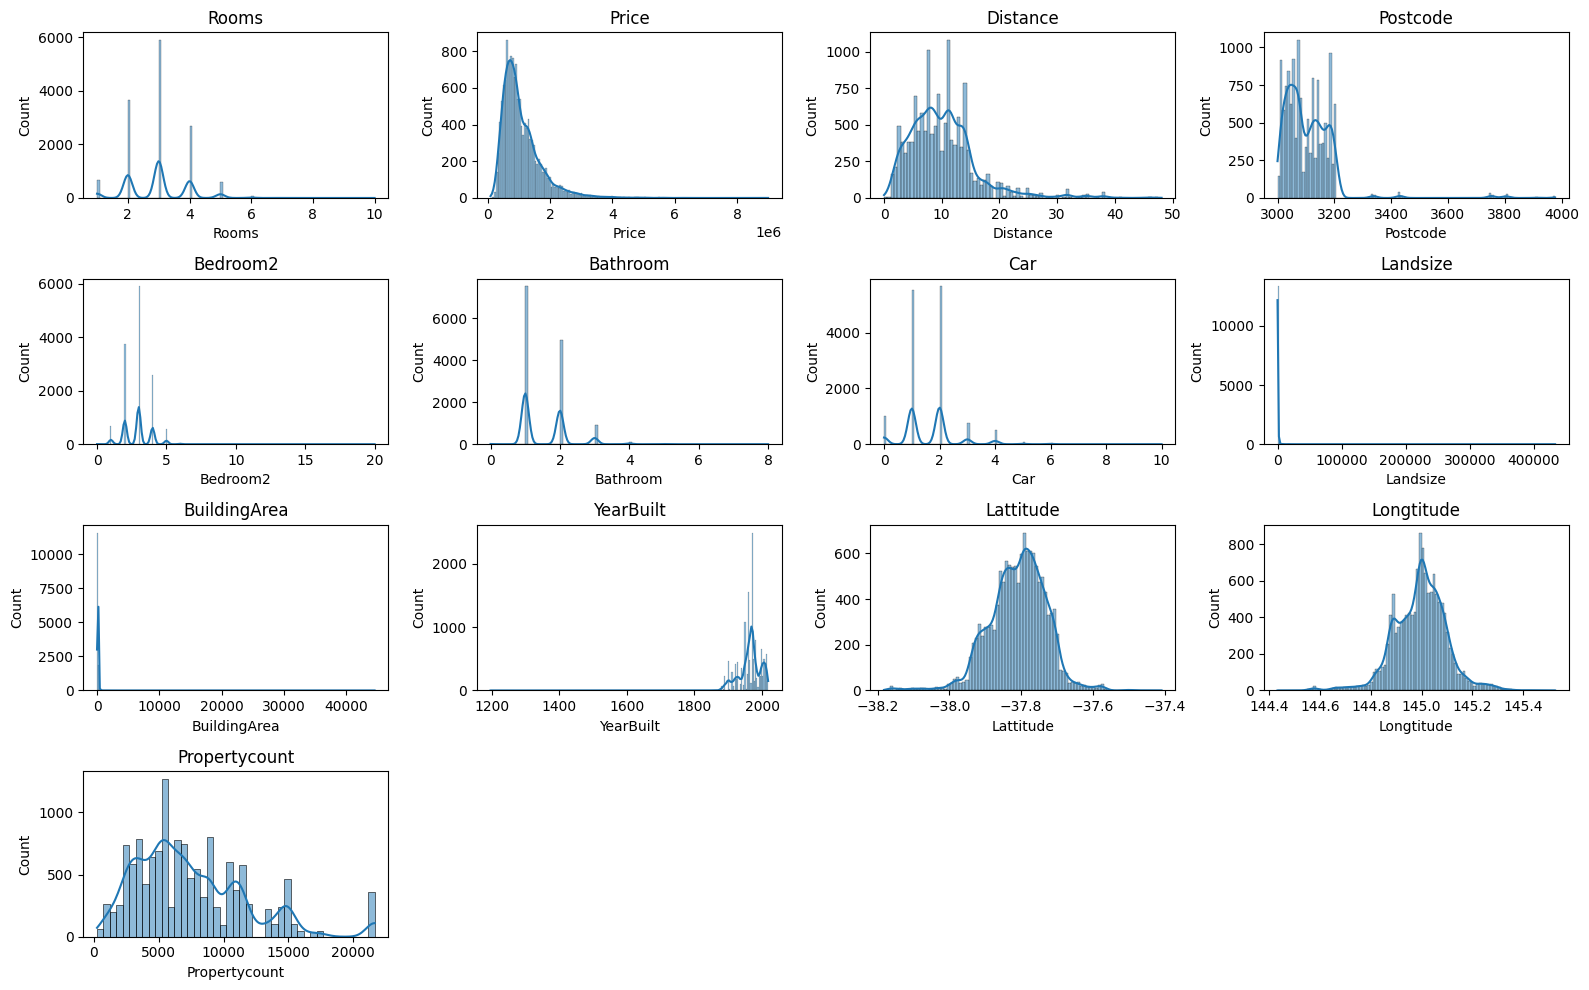

In [39]:
# Histogram Subplots for Distribution Analysis

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(16,10))

for i, col in enumerate(num_cols,1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [42]:
# Extract Altona Data
altona_prices = df_cleaned[df_cleaned['Suburb'] == 'Altona']['Price']
altona_prices

141       520000.0
142      1525000.0
143       720000.0
144      1120000.0
145       780000.0
           ...    
12216     913000.0
12432     458000.0
12634    1248500.0
13338     920000.0
13339     801250.0
Name: Price, Length: 74, dtype: float64

In [43]:
# Perform One-Sample T-Test

t_stat, p_value = ttest_1samp(altona_prices, 800000)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.0277020770199676
P-value: 0.307483271305555


In [45]:
# Since our test is right-tailed, adjust the p-value:
p_value = p_value / 2
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.0277020770199676
P-value: 0.07687081782638874


In [46]:
# Decision Rule
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Fail to reject the null hypothesis


#### Interpretation 

#####  For the suburb of Altona, it is postulated that a typical property sells for $800,000

##### Hypotheses

###### H₀: μ = 800000
###### H₁: μ > 800000

###### A one-sample t-test was conducted at a 5% significance level.

##### Results

###### Test statistic = 1.0277020770199676
###### p-value = 0.07687081782638874

##### Decision
###### Since p-value (0.0769) > α (0.05), we fail to reject the null hypothesis.

##### Conclusion
###### At the 5% significance level, there is insufficient evidence to conclude that the average property price in Altona has increased beyond $800,000.

In [63]:
# Extract Year 2016 Data

# Convert Date Column to Datetime
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], dayfirst=True)

# Extract 2016 Data
df_2016 = df_cleaned[df_cleaned['Date'].dt.year == 2016]
df_2016.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,...,1.0,1.0,202.0,112.0,1935.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0
5,Abbotsford,129 Charles St,2,h,941000.0,S,Jellis,2016-05-07,2.5,3067.0,...,1.0,0.0,181.0,112.0,1935.0,Yarra,-37.8041,144.9953,Northern Metropolitan,4019.0
6,Abbotsford,124 Yarra St,3,h,1876000.0,S,Nelson,2016-05-07,2.5,3067.0,...,2.0,0.0,245.0,210.0,1910.0,Yarra,-37.8024,144.9993,Northern Metropolitan,4019.0


In [65]:
# Create Season Variable (Winter months = Oct, Nov, Dec, Jan, Feb, Mar)

df_2016.loc[:, 'Season'] = df_2016['Date'].dt.month.apply(
    lambda x: 'Winter' if x in [10,11,12,1,2,3] else 'Summer'
)

In [66]:
# Separate Price Groups

winter_prices = df_2016[df_2016['Season'] == 'Winter']['Price']
summer_prices = df_2016[df_2016['Season'] == 'Summer']['Price']

In [72]:
# Run Two-Sample T-Test
t_stat, p_value = ttest_ind(winter_prices, summer_prices)

print("T-statistic:", t_stat)
print("P-value:", p_value)


# Decision Rule
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

T-statistic: 4.043386317851058
P-value: 5.3309767667631686e-05
Reject the null hypothesis


#### Interpretation 

#####  For the year 2016, is there any difference in the prices of properties sold in the summer months vs winter months

##### Hypotheses

###### H₀: μ-winter = μ-summer  (There is no difference in mean property prices between winter and summer months)
###### H₁: μ-winter != μ-summer (There is a difference in mean property prices between winter and summer months)

###### A one-sample t-test was conducted at a 5% significance level.

##### Results

###### Test statistic = 4.043386317851058
###### p-value = 5.3309767667631686e-05

##### Decision
###### Since the p-value (0.000053) is less than the significance level (0.05), we reject the null hypothesis.

##### Conclusion
###### There is sufficient statistical evidence at the 5% significance level to conclude that property prices in winter months differ significantly from those in summer months in 2016.

In [77]:
# Create Car Parking Indicator

df_cleaned['HasCar'] = df_cleaned['Car'].apply(lambda x: 1 if x > 0 else 0)  #1 → Property has car parking & 0 → No car parking
df_cleaned.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,HasCar
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,...,1.0,202.0,112.0,1935.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,1
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,...,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,...,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067.0,...,1.0,94.0,112.0,1935.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,1
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067.0,...,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,1


In [83]:
# Calculate Probability of Car Parking

p = df_cleaned['HasCar'].mean()


print("Probability of car parking:", p)
print("Probability of no car parking:", 1-p)

Probability of car parking: 0.9244477172312224
Probability of no car parking: 0.07555228276877757


In [88]:
# Apply Binomial Distribution

#pmf(k, n, p)
#k = number of successes
#n = number of trials
#p = probability of success

p_no_parking = 1-p

probability = binom.pmf(3, 10, p_no_parking)

print(round(probability, 3))

0.03


#### Interpretation 

##### The probability that 3 out of 10 properties sold in Abbotsford will not have a car parking space is approximately: 0.03

In [89]:
# Filter Abbotsford Data
abbotsford = df_cleaned[df_cleaned['Suburb'] == 'Abbotsford']

In [95]:
# Calculate Probability
probability = (abbotsford['Rooms'] == 3).mean()

print (f"chances of finding a property with 3 rooms : {round(probability*100, 1)}%")

chances of finding a property with 3 rooms : 35.7%


#### Interpretation
##### There is a 35.7% chance that a randomly selected property in Abbotsford has 3 rooms.

In [96]:
# Filter Abbotsford Data

abbotsford = df_cleaned[df_cleaned['Suburb'] == 'Abbotsford']

In [97]:
# Calculate Probability

probability = (abbotsford['Bathroom'] == 2).mean()

print (f"chances of finding a property with 2 bathrooms : {round(probability*100, 1)}%")

chances of finding a property with 2 bathrooms : 33.9%


#### Interpretation
##### There is a 33.9% chance that a randomly selected property in Abbotsford has 2 bathrooms.

In [100]:
# Extract Richmond Prices

richmond_prices = df_cleaned[df_cleaned['Suburb'] == 'Richmond']['Price']

In [103]:
# Perform One-Sample T-Test

t_stat, p_value = ttest_1samp(richmond_prices, 1000000)

print("Test statistic:", t_stat)
print("P-value:", p_value)     # Because this is a two-tailed test, we do not divide the p-value by 2

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Test statistic: 2.579547704074923
P-value: 0.01044499066415202
Reject the null hypothesis


#### Interpretation 

#####  A real estate firm claims that the average property price in Richmond is $1,000,000

##### Hypotheses

###### Null Hypothesis (H₀) μ=1,000,000           (The average property price in Richmond is $1,000,000)

###### Alternative Hypothesis (H₁) μ !=1,000,000  (The average property price in Richmond is different from $1,000,000)

###### A one-sample t-test was conducted at a 5% significance level.

##### Results

###### Test statistic = 2.579547704074923
###### p-value =  0.01044499066415202

##### Decision
###### Since p-value (0.0104) < α (0.05), we reject the null hypothesis.

##### Business Conclusion
###### There is sufficient statistical evidence at the 5% significance level to conclude that the average property price in Richmond is significantly different from $1,000,000.

###### This indicates that the firm's claim about the average price being $1,000,000 may not accurately reflect the actual market price.

In [108]:
# Create Groups

with_parking = df_cleaned[df_cleaned['Car'] > 0]['Price']
without_parking = df_cleaned[df_cleaned['Car'] == 0]['Price']


In [112]:
# Perform Independent T-Test

t_stat, p_value = ttest_ind(with_parking, without_parking)

print("T-statistic:", t_stat)
print("P-value:", p_value)

   

print (f"\n Since the hypothesis is one-tailed (higher price):")

p_value = p_value / 2 

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\n Reject the null hypothesis")
else:
    print("\n Fail to reject the null hypothesis")

T-statistic: -0.17737230371262672
P-value: 0.8592186065441194

 Since the hypothesis is one-tailed (higher price):
T-statistic: -0.17737230371262672
P-value: 0.4296093032720597

 Fail to reject the null hypothesis


#### Interpretation 

##### Do properties with car parking sell at a higher average price than properties without car parking, across the entire dataset

##### Hypotheses

###### Null Hypothesis (H₀) : μ1 ≤ μ2  (Properties with car parking do not sell at a higher average price)

###### Alternative Hypothesis (H₁) : μ1 > μ2 (Properties with car parking sell at a higher average price)

###### A one-sample t-test was conducted at a 5% significance level.

##### Results

###### Test statistic = -0.17737230371262672
###### p-value = 0.4296093032720597

##### Decision
###### Since p-value (0.4296) > α (0.05), we fail to reject the null hypothesis.

##### Business Conclusion
###### The analysis indicates that the presence of car parking does not significantly increase property prices across the dataset at the 5% significance level. While parking may still be a desirable feature for buyers, the statistical evidence suggests it does not necessarily lead to higher average selling prices. Developers should therefore consider other factors such as location, property size, and amenities when aiming to increase property value.

In [116]:
# Fit the ANOVA Model

model = ols('Price ~ C(Suburb) * C(Type)', data=df_cleaned).fit()

# C(Suburb)        → suburb effect
# C(Type)          → property type effect
# C(Suburb):C(Type) → interaction effect

# Run Two-Way ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

C:\Users\godse\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 313, but rank is 150
  warnings.warn('covariance of constraints does not have full '
C:\Users\godse\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 0
  warnings.warn('covariance of constraints does not have full '
C:\Users\godse\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J


                         sum_sq       df          F         PR(>F)
C(Suburb)          3.947162e+15    313.0  78.579421   0.000000e+00
C(Type)                     NaN      2.0        NaN            NaN
C(Suburb):C(Type)  6.470034e+14    626.0   6.440216  2.505093e-263
Residual           2.068639e+15  12890.0        NaN            NaN


C:\Users\godse\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 626, but rank is 375
  warnings.warn('covariance of constraints does not have full '


In [117]:
# Filter Suburbs

df_anova = df_cleaned[df_cleaned['Suburb'].isin(['Abbotsford','Altona','Richmond'])]

# Run Two-Way ANOVA

model = ols('Price ~ C(Suburb) * C(Type)', data=df_anova).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                         sum_sq     df           F        PR(>F)
C(Suburb)          4.071631e+12    2.0   17.867719  3.826443e-08
C(Type)            3.880576e+13    2.0  170.293035  1.453172e-53
C(Suburb):C(Type)  1.836479e+12    4.0    4.029551  3.259122e-03
Residual           4.341045e+13  381.0         NaN           NaN


#### Interpretation

##### Suburb Effect
###### The p-value for suburb is 3.83e-08, which is less than the significance level of 0.05. Therefore, suburb has a significant effect on property prices, indicating that average property prices differ across locations.

##### Property Type Effect
###### The p-value for property type is 1.45e-53, which is far below 0.05. This indicates that property type significantly influences property prices, meaning houses, townhouses, and units have different average prices.

##### Interaction Effect
###### The p-value for the interaction between suburb and property type is 0.00326, which is also below 0.05. This suggests that the effect of property type on price varies depending on the suburb.

#### Business Interpretation
##### The results indicate that both location and property type significantly influence property prices, and their interaction also plays an important role. Developers and investors should therefore consider both the suburb and the type of property being developed, as the value of different property types can vary significantly depending on the location.

In [120]:
# Create Groups

more_bath = df_cleaned[df_cleaned['Bathroom'] > 2]['Price']
less_bath = df_cleaned[df_cleaned['Bathroom'] <= 2]['Price']

In [122]:
# Perform Two-Sample T-Test

t_stat, p_value = ttest_ind(more_bath, less_bath)

p_value = p_value / 2  # one-tailed test

print("Test statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\n Reject the null hypothesis")
else:
    print("\n Fail to reject the null hypothesis")

Test statistic: 46.02604887995347
P-value: 0.0

 Reject the null hypothesis


#### Interpretation 

#####  for A housing policy group believes that properties with more than 2 bathrooms command a premium price.

##### Hypotheses

###### Null Hypothesis (H₀) : 𝜇1 ≤ 𝜇2  (Properties with more than 2 bathrooms do not sell at higher prices)

###### Alternative Hypothesis (H₁) : 𝜇1 > 𝜇2 (Properties with more than 2 bathrooms sell at higher prices)


##### Results

###### Test statistic = 46.03
###### p-value ≈ 0.000

##### Decision
###### Since p-value (0.00) < α (0.05), we reject the null hypothesis.

##### Business Conclusion
###### The statistical analysis provides strong evidence that properties with more than two bathrooms command significantly higher prices. This suggests that additional bathrooms are associated with a price premium in the housing market. Policymakers and housing planners should consider encouraging housing developments with additional bathrooms, as this feature appears to increase property value and market attractiveness.